# Trabajo Práctico III - Visión por Computadora I

Alumnos:
- Maximiliano Christener
- Ronald Uthurralt
- Luis David Díaz Charris
- Juan Pablo Skobalski

### **Consigna**

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/images` a partir del template `Material_TPs/TP3/template`.


Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección.




1. **(4 puntos) Obtener una detección del logo en cada imagen sin falsos positivos**

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [3]:
def preparar_bordes(img):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Canny extrae la silueta. Ajusta los umbrales (50, 150) según veas el resultado
    bordes = cv.Canny(gray, 50, 150)
    # Convertimos de nuevo a 3 canales porque SIFT a veces se queja si no hay consistencia
    return cv.cvtColor(bordes, cv.COLOR_GRAY2BGR)

# Aplicar a ambas


In [4]:
def purificar_logo(img):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Crea un mapa binario que resalta las letras sobre el fondo
    thresh = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                  cv.THRESH_BINARY_INV, 11, 2)
    return thresh



Puntos clave en logo: 152
Puntos clave en escena: 2898
Coincidencias encontradas: 1
Coincidencias encontradas: 1
No hay suficientes puntos para la homografía


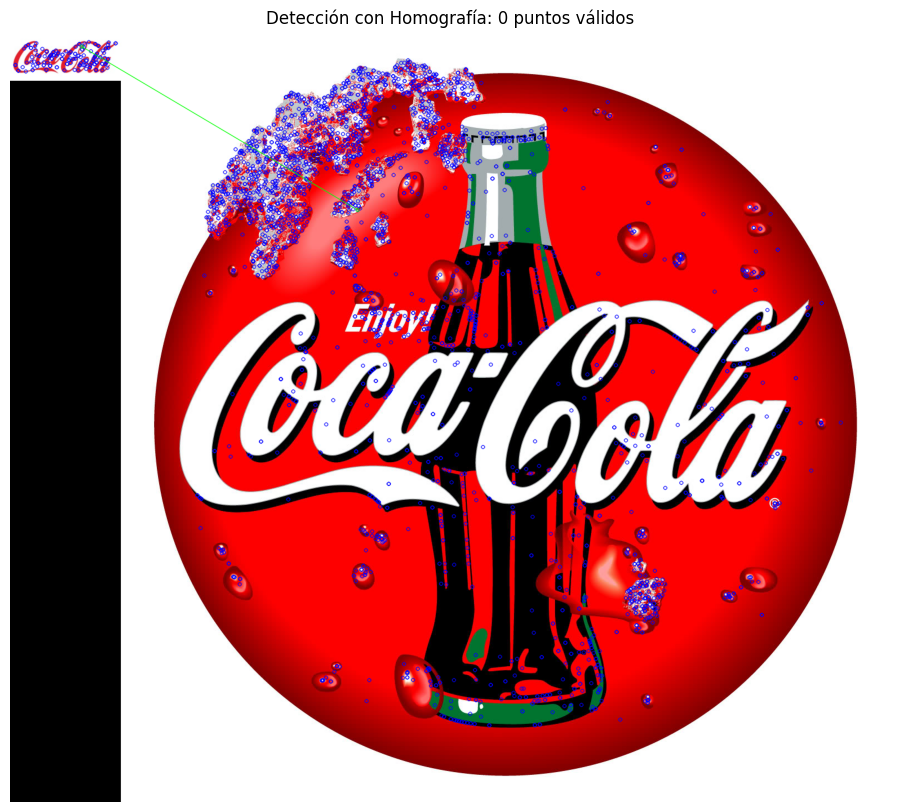

In [12]:
# 1. Cargar imágenes

img1 = cv.imread('template/pattern.png')
img2 = cv.imread('images/COCA-COLA-LOGO.jpg')

# Verificación de carga
if img1 is None:
    print(f"Error cargando {img1}'")
elif img2 is None:
    print(f"Error cargando {img2}")
else:
    # --- PRE-PROCESAMIENTO ---
    # 1. Reducir template
    img1_res = cv.resize(img1, (0,0), fx=0.5, fy=0.5)

    # 2. Aplicar un poco de Blur al template para quitarle lo "digital"
    img1_blur = cv.GaussianBlur(img1_res, (3,3), 0)

    # 3. Convertir ambos a Bordes Canny (esto iguala el "estilo")
    # Es mucho más probable que las siluetas coincidan
    img1_prefinal = purificar_logo(img1_blur)
    img1_final = cv.Canny(cv.cvtColor(img1_prefinal, cv.COLOR_GRAY2BGR), 100, 200) #img1_blur
    
    img2_final = cv.Canny(cv.cvtColor(img2, cv.COLOR_BGR2GRAY), 100, 200)

    # --- SIFT ---
    sift = cv.SIFT_create(contrastThreshold=0.01, edgeThreshold=20)
    kp1, des1 = sift.detectAndCompute(img1_final, None)
    kp2, des2 = sift.detectAndCompute(img2_final, None)

    
    # 5. Cargar el BFMatcher (Brute Force Matcher)
    bf = cv.BFMatcher()
    
    # 6. Emparejar descriptores con k=2
    matches = bf.knnMatch(des1, des2, k=2)

    # 7. Aplicar el Lowe's Ratio Test (Este es el filtro crucial)
    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append([m])

    print(f"Puntos clave en logo: {len(kp1)}")
    print(f"Puntos clave en escena: {len(kp2)}")
    print(f"Coincidencias encontradas: {len(good)}")

    print(f"Coincidencias encontradas: {len(good)}")

    # ==========================================
    # 8. CÁLCULO DE HOMOGRAFÍA Y FILTRADO DE OUTLIERS
    # ==========================================

    # Extraemos los puntos de la lista 'good' (necesitamos aplanarla primero)
    good_flat = [m[0] for m in good]

    if len(good_flat) >= 4:
        # 1. Extraer coordenadas de los puntos
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_flat]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_flat]).reshape(-1, 1, 2)

        # --- AJUSTE DE ESCALA ---
        # Como img1_res tiene fx=0.5, los puntos están a la mitad de su tamaño original.
        # Los multiplicamos por 2 para que el polígono encaje en el pattern original.
        src_pts = src_pts * 2.0 

        # 2. RANSAC: El héroe que elimina el outlier de "Cafeína"
        # mask nos dirá qué puntos son reales (1) y cuáles son mentira (0)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 2.0)
        
        # matchesMask = mask.ravel().tolist()
        matchesMask = [[m] for m in mask.ravel().tolist()]

        # 3. Dibujar el recuadro verde si se encontró la matriz
    
        if M is not None:
            # 1. Ajustar máscara para drawMatchesKnn (Lista de listas)
            # RANSAC devuelve [1, 0, 1...], Knn espera [[1], [0], [1]...]
            matchesMask = [[int(m)] for m in mask.ravel().tolist()]
            
            # 2. Calcular el recuadro
            h, w = img1.shape[:2]
            pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
            dst = cv.perspectiveTransform(pts, M)

            # 3. Dibujar sobre la escena original
            img2_poligono = cv.polylines(img2.copy(), [np.int32(dst)], True, (0, 255, 0), 10, cv.LINE_AA)
        else:
            img2_poligono = img2
            matchesMask = None

    else:
        print("No hay suficientes puntos para la homografía")
        matchesMask = None
        img2_poligono = img2

    # ==========================================
    # 9. GENERAR EL GRÁFICO FINAL (Limpiando Outliers)
    # ==========================================

    # Ahora drawMatchesKnn usará matchesMask para NO dibujar la línea del outlier
    draw_params = dict(matchColor = (0,255,0), # líneas verdes para los inliers
                    singlePointColor = (255,0,0),
                    matchesMask = matchesMask, # <--- AQUÍ SE BORRA EL OUTLIER
                    flags = cv.DrawMatchesFlags_DEFAULT)

    img_final = cv.drawMatchesKnn(
        img1_res, kp1, 
        img2_poligono, kp2, 
        good, None, **draw_params
    )

    # 10. Mostrar con Matplotlib
    plt.figure(figsize=(18, 10))
    plt.imshow(cv.cvtColor(img_final, cv.COLOR_BGR2RGB))

    # Contamos los inliers correctamente
    if matchesMask is not None:
        puntos_validos = sum([m[0] for m in matchesMask])
    else:
        puntos_validos = 0

    plt.title(f"Detección con Homografía: {puntos_validos} puntos válidos")
    plt.axis('off')
    plt.show()

2. **(4 puntos) Plantear y validar un algoritmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo témplate del ítem 1**

3. **(2 puntos) Generalizar el algoritmo del item 2 para todas las imágenes.**